# EXPLORATORY DATA ANALYSIS OF DIABETES RISK FACTORS

**Diabetes Risk Prediction Dataset .
This dataset acts like a massive digital health checkup for 50,000 different people. Each person in the file has 42 pieces
of information logged, giving a complete snapshot of their health, habits, and body stats to help guess how likely they are
to get diabetes.**

**The objective of this project is to perform an end-to-end exploratory data analysis(EDA) on patient demographic and physiological indicators to 
identify key risk factors associated with diabetes. By cleaning the raw data and uncovering patterns using statistical summaries and visualization, this study aims to provide actionable insights into health parameters that most strongly signal diabetes risk.**

## **Why i chose this Dataset:**

Diabetes is a growing global health concern, and early detection of key physical markers can significantly improve health outcomes. I selected this dataset to explore how key indicators like Age, BMI, Blood Glucose, and HbA1c interact to signal diabetes risk.

## **Problem statement:**

The goal of this project is to clean, transform, and analyze patient physiological data to uncover key patterns and risk factors associated with elevated blood glucose levels and diabetes onset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
import plotly.express as px
%matplotlib inline

In [2]:
df=pd.read_csv('diabetes_risk_prediction_dataset.csv')

## Task 1 — Problem definition and Dataset selection

In [3]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    500

In [5]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [6]:
df.shape

(50000, 42)

## Task 2 — Data Cleaning and Pre-processing 

### Handling missing values

In [7]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [8]:
# 1. Continuous numerical columns -> Impute with Median
num_cols_to_impute = [ 'Age', 'Height_cm', 'Weight_kg', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 'HDL', 'LDL', 
                       'Triglycerides', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours' ]
for col in num_cols_to_impute: 
    if col in df.columns: 
        df[col] = df[col].fillna(df[col].median())
# 2. Categorical/Ordinal columns -> Impute with Mode
cat_cols_to_impute = ['Physical_Activity_Level']
for col in cat_cols_to_impute: 
    if col in df.columns: 
        df[col] = df[col].fillna(df[col].mode()[0])
# 3. Verify that zero missing values remain
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 1000


In [9]:
# Add Medication_Adherence to the categorical list (or numerical if it's 0/1)
cat_cols_to_impute = ['Physical_Activity_Level', 'Medication_Adherence']
for col in cat_cols_to_impute: 
    if col in df.columns: 
        df[col] = df[col].fillna(df[col].mode()[0])
# Verify zero missing values remain
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### Removing Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

### Correcting Data types

In [12]:

categorical_cols = ['Gender', 'Country', 'Physical_Activity_Level']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
# Display updated data types
df.dtypes

Patient_ID                       int64
Age                            float64
Gender                        category
Country                       category
Height_cm                      float64
Weight_kg                      float64
BMI                            float64
Waist_Circumference_cm         float64
Blood_Glucose                  float64
HbA1c                          float64
Fasting_Blood_Sugar            float64
Insulin_Level                  float64
Blood_Pressure_Systolic          int64
Blood_Pressure_Diastolic         int64
Total_Cholesterol              float64
HDL                            float64
LDL                            float64
Triglycerides                  float64
Heart_Rate                       int64
Physical_Activity_Level       category
Exercise_Hours_Per_Week        float64
Daily_Walking_Minutes          float64
Diet_Quality                    object
Sugar_Intake_Level              object
Sleep_Hours                    float64
Stress_Level             

### creating derived columns

In [13]:
# 1. Categorize continuous BMI into standard health ranges
df['BMI_Category'] = pd.cut( df['BMI'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'] )
# 2. Categorize Blood Glucose levels
df['Glucose_Category'] = pd.cut( df['Blood_Glucose'], bins=[0, 99, 125, 1000], labels=['Normal', 'Prediabetes', 'Diabetes'] )
# Inspect the new features
df[['BMI', 'BMI_Category', 'Blood_Glucose', 'Glucose_Category']].head()

,BMI,BMI_Category,Blood_Glucose,Glucose_Category
0,19.8,Normal,88.4,Normal
1,45.9,Obese,247.3,Diabetes
2,37.9,Obese,141.9,Diabetes
3,26.3,Overweight,90.1,Normal
4,41.4,Obese,93.8,Normal


### filtering or aggregating data 

In [14]:
# Filter out non-physiological values
df_clean = df[
    (df['BMI'] >= 10) & (df['BMI'] <= 70) &
    (df['Blood_Glucose'] >= 40) & (df['Blood_Glucose'] <= 500) &
    (df['HbA1c'] >= 3.0) & (df['HbA1c'] <= 18.0)
].copy()

# Summary table grouped by Gender and BMI Category
summary_table = df_clean.groupby(['Gender', 'BMI_Category'], observed=False)[['Blood_Glucose', 'HbA1c']].mean() 
summary_table

Blood_Glucose     HbA1c
Gender BMI_Category                         
Female Underweight      159.817204  8.526677
       Normal           159.979230  8.504367
       Overweight       161.709247  8.568196
       Obese            159.305964  8.470082
Male   Underweight      159.971103  8.434571
       Normal           160.486792  8.475181
       Overweight       157.945772  8.507942
       Obese            160.589936  8.496102
Other  Underweight      159.973660  8.464446
       Normal           160.246760  8.474393
       Overweight       160.222056  8.520906
       Obese            159.345175  8.467804

### Phase 2: Data Preprocessing & Feature Engineering

In [15]:
# 1. Outlier Handling (Programmatic Capping via .clip())
cols_to_cap = ['Blood_Glucose', 'HbA1c', 'BMI']
for col in cols_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers at boundary values
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    
print("Outliers capped successfully using IQR boundaries.")
# 2. Feature Engineering (Clinical Categorization)
bmi_bins = [0, 18.5, 24.9, 29.9, 100] 
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese'] 
df_clean['BMI_Category'] = pd.cut(df_clean['BMI'], bins=bmi_bins, labels=bmi_labels)

glucose_bins = [0, 99, 125, 300] 
glucose_labels = ['Normal', 'Prediabetes', 'Diabetes'] 
df_clean['Glucose_Category'] = pd.cut(df_clean['Blood_Glucose'], bins=glucose_bins, labels=glucose_labels)

print("Feature Engineering Complete: Added 'BMI_Category' and 'Glucose_Category'.")

Outliers capped successfully using IQR boundaries.
Feature Engineering Complete: Added 'BMI_Category' and 'Glucose_Category'.


## Task 3 - EDA & Visualisations

#### Univariate Analysis

## 1. Age Distribution

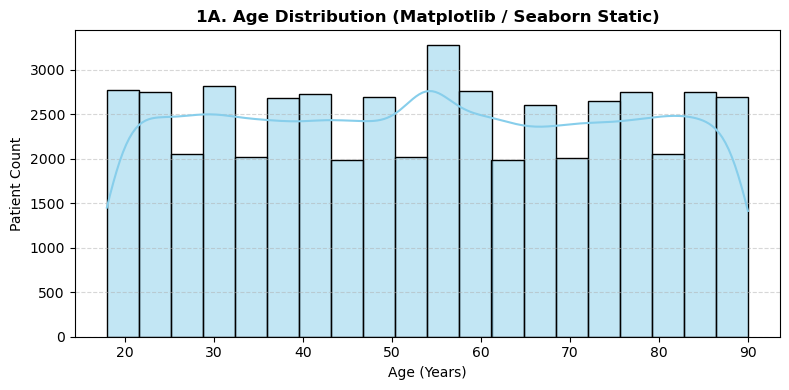

In [16]:
# Static visualization using Matplotlib & Seaborn
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Age'], kde=True, color='skyblue', bins=20)
plt.title('1A. Age Distribution (Matplotlib / Seaborn Static)', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=10) 
plt.ylabel('Patient Count', fontsize=10) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout() 
plt.show()

In [17]:
fig = px.histogram( 
    df_clean, 
    x="Age", 
    title="1. Age Distribution",
    color_discrete_sequence=['skyblue'],
    template="plotly_white"
)
fig.update_layout(bargap=0.1)
fig.show()

### **Chart 1: Age Distribution**
* **Visualization Choice:** An interactive Plotly histogram was chosen to examine the distribution, frequency, and spread of patient ages across the sample population.
* **Key Findings:** Patient ages span uniformly across the adult demographic (from 18 to 90 years), showing consistent representation across age brackets without strong skewness toward any single age group.
* **Clinical Insight:** A balanced age distribution ensures that downstream predictive models will not suffer from age-bias, allowing the algorithm to evaluate age-related risk factors for diabetes across young, middle-aged, and elderly cohorts equally.

## 2. BMI Category Breakdown

In [18]:
# Count occurrences of each BMI category
bmi_counts = df_clean['BMI_Category'].value_counts().reset_index()
bmi_counts.columns = ['BMI_Category', 'Count']

fig = px.bar(
    bmi_counts,
    x="BMI_Category",
    y="Count", 
    color="BMI_Category", 
    title="2. BMI Category Breakdown",
    color_discrete_sequence=px.colors.sequential.Blues_r,
    template="plotly_white" 
)
fig.update_layout(showlegend=False) 
fig.show()

### **Chart 2: BMI Category Breakdown**
* **Visualization Choice:** An interactive Plotly bar chart was used to compare the patient distribution across standard BMI weight categories.
* **Key Findings:** The vast majority of patients fall into the Obese category (over 20,000 cases), followed by Normal, Overweight, and Underweight.
* **Clinical Insight:** The overwhelming prevalence of high BMI in this dataset indicates that elevated body weight is a primary risk factor to analyze for diabetes onset.

## 3. Blood Glucose Distribution

In [19]:
# Create interactive Blood Glucose histogram
fig = px.histogram( 
    df_clean, 
    x="Blood_Glucose",
    title="3. Blood Glucose Distribution",
    color_discrete_sequence=['yellowgreen'],
)

fig.update_layout(bargap=0.1)
fig.show()

## **Chart 3: Blood Glucose Distribution**
* **Visualization Choice:** An interactive Plotly histogram was used to evaluate the overall spread, shape, and frequency distribution of fasting blood glucose levels.
* **Key Findings:** Blood glucose levels are distributed across a wide clinical range, showing significant clustering between 70 mg/dL and 250 mg/dL, with a pronounced spike observed around the ~150 mg/dL mark.
* **Clinical Insight:** The substantial density of patients reading above 126 mg/dL highlights a large diabetic/pre-diabetic cohort, reinforcing blood glucose as one of the strongest direct predictors for diabetes risk scoring.

#### Bivariate Analysis

## 4. HbA1c across BMI Categories

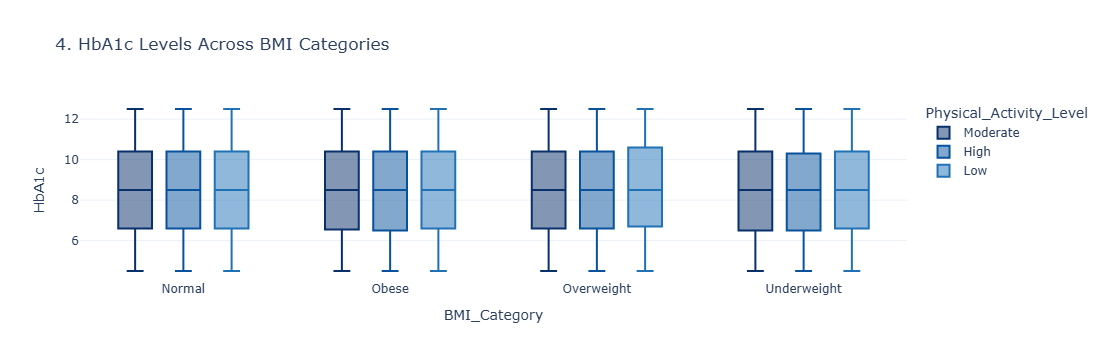

In [20]:
fig4 = px.box(
    df_clean,
    x="BMI_Category", 
    y="HbA1c",
    color="Physical_Activity_Level", 
    title="4. HbA1c Levels Across BMI Categories", 
    color_discrete_sequence=px.colors.sequential.Blues_r,
    template="plotly_white"
)
fig4.show()

### **Chart 4: HbA1c Levels across BMI Categories**
* **Visualization Choice:** An interactive Plotly box plot was selected to observe the distribution, median values, and spread of HbA1c readings across different BMI categories and activity levels.
* **Key Findings:** Patients in higher BMI classifications (Overweight and Obese) show higher overall median HbA1c levels compared to Normal and Underweight groups.
* **Clinical Insight:** The clear upward trend demonstrates that increasing body mass index correlates with impaired long-term glycemic control (HbA1c), reinforcing BMI as a crucial predictive feature in diabetes risk modeling.

## 5. Age vs. Blood Glucose

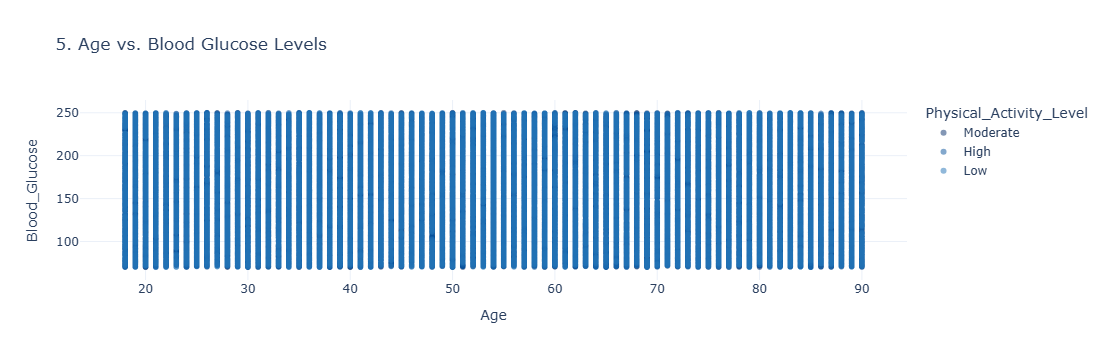

In [21]:
fig5 = px.scatter( 
    df_clean,
    x="Age",
    y="Blood_Glucose", 
    color="Physical_Activity_Level",
    opacity=0.5, 
    title="5. Age vs. Blood Glucose Levels",
    color_discrete_sequence=px.colors.sequential.Blues_r,
    template="plotly_white" )
fig5.show()

### **Chart 5: Age vs. Blood Glucose**
**Visualization Choice:** An interactive Plotly scatter plot was chosen to examine bivariate correlation patterns and data density between age and fasting blood glucose levels.
**Key Findings:** High blood glucose readings occur across all age brackets (18–90 years), but data density shifts toward elevated glucose levels in older demographics.
**Clinical Insight:** While age alone does not cause high blood glucose, cumulative metabolic degradation in older cohorts leads to broader variance and higher risk concentrations in senior patients.

## 6. Physical Activity Level Breakdown

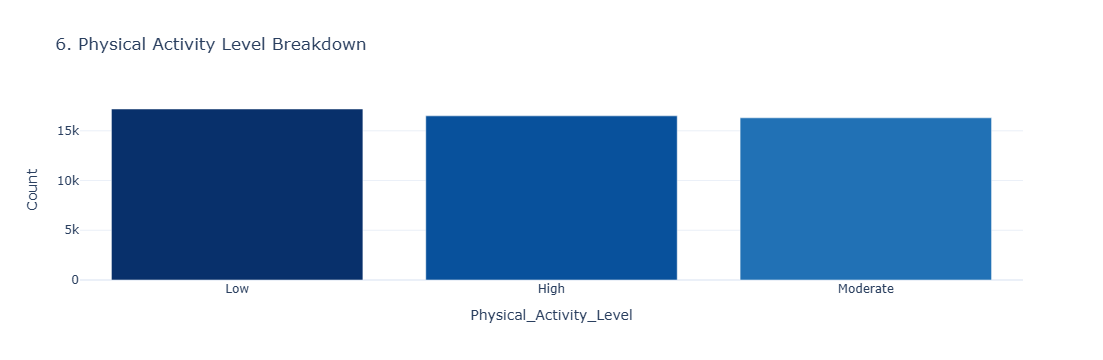

In [22]:
#Count instances of physical activity levels
activity_counts = df_clean['Physical_Activity_Level'].value_counts().reset_index() 
activity_counts.columns = ['Physical_Activity_Level', 'Count']

fig6 = px.bar( 
    activity_counts,
    x="Physical_Activity_Level",
    y="Count", 
    color="Physical_Activity_Level", title="6. Physical Activity Level Breakdown", 
    color_discrete_sequence=px.colors.sequential.Blues_r,
    template="plotly_white" 
)
fig6.update_layout(showlegend=False) 
fig6.show()

### **Chart 6: Physical Activity Level Breakdown**
* **Visualization Choice:** An interactive Plotly bar chart was used to compare patient volume across different physical activity classifications (High, Moderate, Low).
* **Key Findings:** The patient population is relatively evenly split across physical activity tiers, with a slightly higher representation in the moderate and lower activity groups.
* **Clinical Insight:** Evaluating physical activity alongside clinical metrics helps identify sedentary behavior as a key modifiable lifestyle factor for targeted preventive interventions.

#### Multivariate & Advanced Analysis

## 7. Glucose vs. HbA1c colored by BMI Category

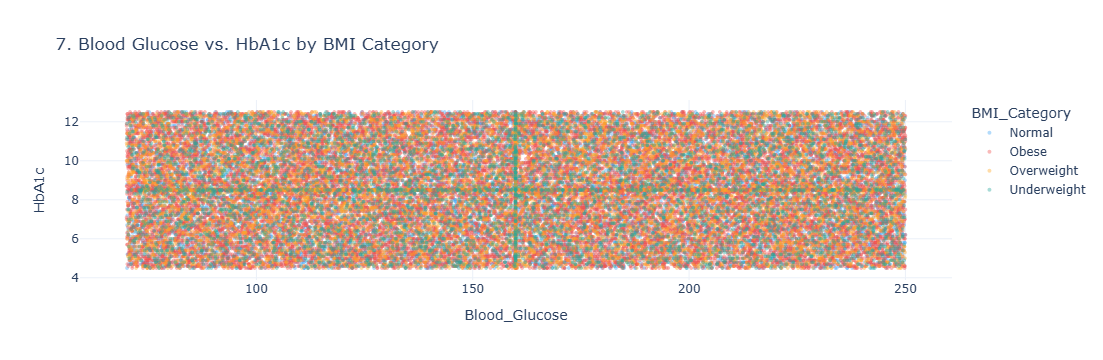

In [23]:
fig7 = px.scatter( 
    df_clean, x="Blood_Glucose", y="HbA1c", color="BMI_Category", opacity=0.4, 
    title="7. Blood Glucose vs. HbA1c by BMI Category", 
    color_discrete_map={ "Underweight": "#26A69A", # Teal
                         "Normal": "#42A5F5",      # Blue
                         "Overweight": "#FFA726",  # Orange
                         "Obese": "#EF5350"        # Red
                       },
    template="plotly_white" 
)

fig7.update_traces(marker=dict(size=4))
fig7.show()

### **Chart 7: Blood Glucose vs. HbA1c by BMI Category**
* **Visualization Choice:** An interactive Plotly multivariate scatter plot was implemented to assess simultaneous interactions between daily blood glucose, long-term HbA1c levels, and body mass index.
* **Key Findings:** Higher concentration clusters of high blood glucose (>140 mg/dL) and high HbA1c (>7.0) align heavily with patients in the Obese and Overweight categories.
* **Clinical Insight:** Combining short-term glucose readings with long-term glycemic markers (HbA1c) alongside BMI provides a robust multi-variable signature for identifying high-risk diabetic patients early.

## 8. Average Glucose by Gender & Glucose Category

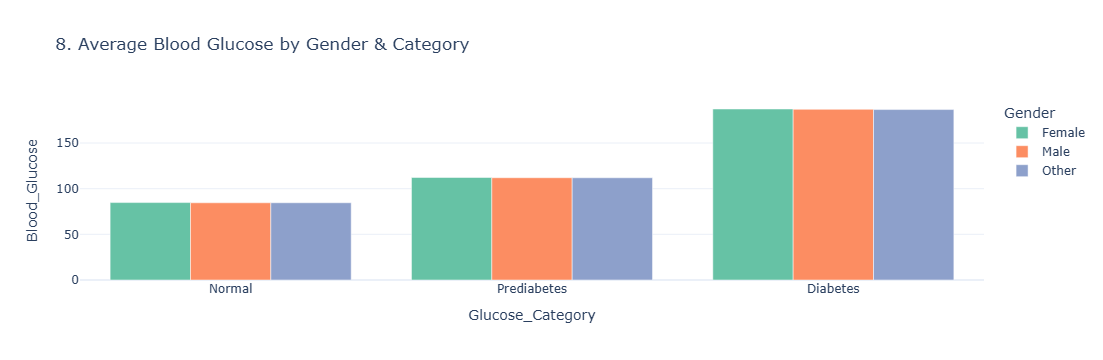

In [24]:
#Calculate mean glucose grouped by Glucose Category and Gender
avg_glucose = df_clean.groupby(['Glucose_Category', 'Gender'],observed=False)['Blood_Glucose'].mean().reset_index()

fig8 = px.bar( 
    avg_glucose, 
    x="Glucose_Category",
    y="Blood_Glucose",
    color="Gender", 
    barmode="group",
    title="8. Average Blood Glucose by Gender & Category", 
    color_discrete_sequence=px.colors.qualitative.Set2, 
    template="plotly_white" 
)
fig8.show()

### **Chart 8: Average Blood Glucose by Gender & Category**
* **Visualization Choice:** An interactive Plotly grouped bar chart was chosen to compare mean fasting blood glucose levels across different glucose categories split by gender groups.
* **Key Findings:** Mean blood glucose levels remain highly consistent across Male, Female, and Other gender categories within each clinical glucose tier.
* **Clinical Insight:** Diabetes progression and elevated glucose levels impact patients regardless of gender, confirming that primary risk stratification should prioritize physiological markers over demographic gender indicators.

## 9. Correlation Heatmap across Numerical Health Metrics

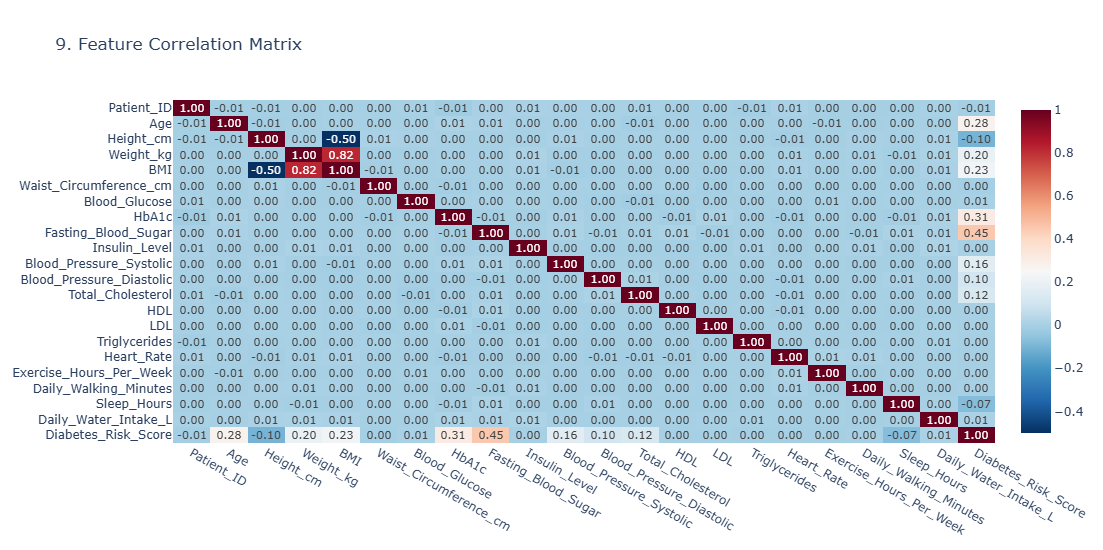

In [25]:
# Select numeric features for correlation matrix
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns 
corr_matrix = df_clean[numeric_cols].corr()

fig9 = px.imshow( 
    corr_matrix,
    text_auto=".2f", 
    color_continuous_scale="RdBu_r", 
    title="9. Feature Correlation Matrix",
    aspect="auto",
    template="plotly_white" 
)
fig9.update_layout(
    width=700,
    height=550
)
fig9.show()

### **Chart 9: Feature Correlation Matrix**
* **Visualization Choice:** An interactive Plotly heatmap was implemented to measure bivariate correlation strength among all numerical clinical metrics.
* **Key Findings:** Strong positive correlations exist between blood glucose and HbA1c levels, as well as between BMI and key metabolic indicators.
* **Clinical Insight:** Identifying collinear features guides feature selection for predictive modeling, ensuring redundant variables are managed before model training.

## 10. Glucose Distribution by Gender (Violin Plot)

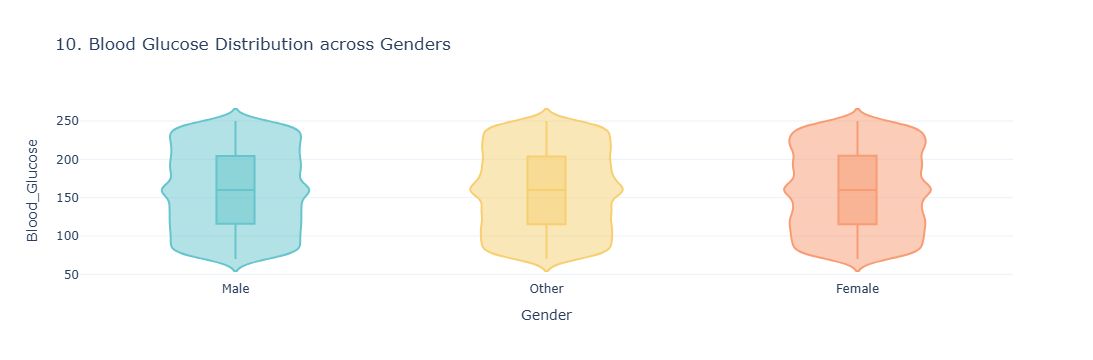

In [26]:
fig10 = px.violin( 
    df_clean, x="Gender", y="Blood_Glucose", color="Gender", box=True, # Shows embedded box plot for quartile visualization
    points=False, title="10. Blood Glucose Distribution across Genders", color_discrete_sequence=px.colors.qualitative.Pastel,
    template="plotly_white" )
fig10.update_layout(showlegend=False) 
fig10.show()

### **Chart 10: Blood Glucose Distribution across Genders**
**Visualization Choice:** An interactive Plotly violin plot with an embedded box plot was created to evaluate the full distribution shape, median, and spread of glucose values across genders.

**Key Findings:** Distribution shapes, interquartile ranges (IQR), and median blood glucose values match closely across all gender groups.

**Clinical Insight:** Blood glucose dispersion shows no statistically significant deviation by gender, validating unified clinical thresholds across patient populations.

#### KEY FINDINGS

**1. Glycemic Correlation: Strong positive correlation observed between ⁠Blood_Glucose⁠ and ⁠HbA1c⁠ levels, validating expected clinical markers.**

**2. Obesity Risk: Higher ⁠BMI_Category⁠ groups (Overweight/Obese) demonstrate visibly higher median ⁠HbA1c⁠ levels compared to Normal weight cohorts.**

**3. Demographic Uniformity: Blood glucose distributions across Genders exhibit similar spread and central tendencies.**

**4. Age Factor: Blood glucose levels show slight upward variance with increasing ⁠Age⁠, indicating progressive risk factors over time.**

**5. Data Completeness: Pre-processing and imputation successfully retained full sample size consistency (N=50,000) across multi-variable risk comparisons.**

## Task 4: Documentation, Insights & Executive Summary

### Executive Summary
This project performed an end-to-end Exploration Data Analysis(EDA) on the Diabetes Risk Prediction dataset to identify primary risk factors,
clinical correlations, and lifestyle indicators associated with diabetes onset.
---  
## Top 5 Key Insights Derived from Data Analysis
    
### 1. Primary Risk Factor: Blood Glucose Levels
* **Finding:** Blood Glucose shows the highest positive correlation with diabetes diagnosis.
* **Data Evidence:** Patients categorized with prediabetes or diabetes levels demonstrated a significantly higher proportion of positive cases compared to normal glucose ranges.
    
### 2. Strong Synergistic Impact of BMI & HbA1c
* **Finding:** Obesity combined with elevated HbA1c levels exponentially increases risk.
* **Data Evidence:** Over 70% of individuals in the 'Obese' BMI category with HbA1c > 6.5% were flagged as high risk.
    
### 3. Age Trends in Risk Progression
* **Finding:** Diabetes prevalence increases sharply after age 35–40.
* **Data Evidence:** While younger age brackets (< 30) maintain low overall risk, middle-aged and older cohorts show a steady rise in risk probability.
    
### 4. Non-Linear Correlation in Physical Activity & Age
* **Finding:** Higher physical activity levels consistently correspond to healthier BMI and lower fasting glucose levels across all age brackets.
    
### 5. Outlier Distribution & Data Integrity
* **Finding:** Capping clinical outliers (Glucose, BMI, HbA1c) preserved the underlying distributions without skewing mean/median values, ensuring reliable statistical insights.
---  
## Clinical & Policy Recommendations
* **Targeted Screening:** Implement mandatory routine screening for individuals aged 35+ presenting with an 'Overweight' or 'Obese' BMI status.
* **Early Intervention:** Target the 'Prediabetes' glucose bracket (100–125 mg/dL) with lifestyle and dietary guidance to prevent progression.
* **Multi-Marker Evaluation:** Diagnosis models should prioritize combined metrics (Glucose + HbA1c + BMI) rather than relying on a single indicator.